In [ ]:
#Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Chargement de dataset
df = pd.read_csv('World_happiness_clean.csv')

In [ ]:
df.head()

,Unnamed: 0,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [ ]:
#Suppression de la colonne Unnamed: 0
df = df.drop('Unnamed: 0', axis=1)

In [ ]:
df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual,Year
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738,2015
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201,2015
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204,2015
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531,2015
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176,2015


In [ ]:
#Vérification des valeurs manquantes
df.isnull().sum()

,0
Country,0
Region,0
Happiness Rank,0
Happiness Score,0
Standard Error,0
Economy (GDP per Capita),0
Family,0
Health (Life Expectancy),0
Freedom,0
Trust (Government Corruption),0


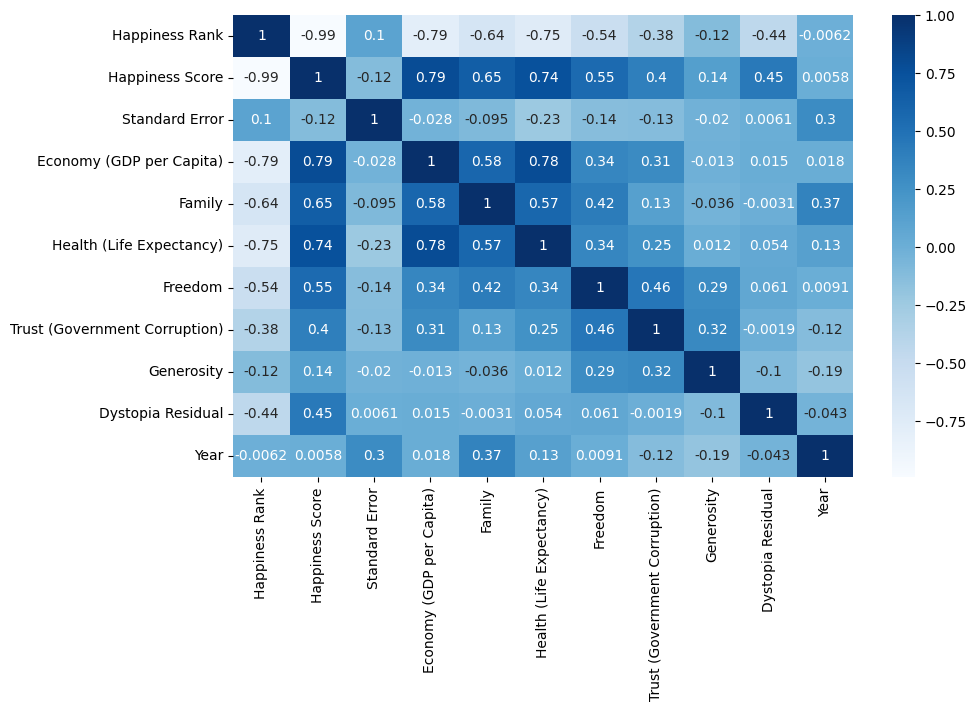

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues');

In [ ]:
df.corr(numeric_only=True)['Happiness Rank'].sort_values(ascending=True)

,Happiness Rank
Happiness Score,-0.992097
Economy (GDP per Capita),-0.794330
Health (Life Expectancy),-0.745446
Family,-0.643998
Freedom,-0.537115
Dystopia Residual,-0.444711
Trust (Government Corruption),-0.375436
Generosity,-0.119457
Year,-0.006249
Standard Error,0.103065


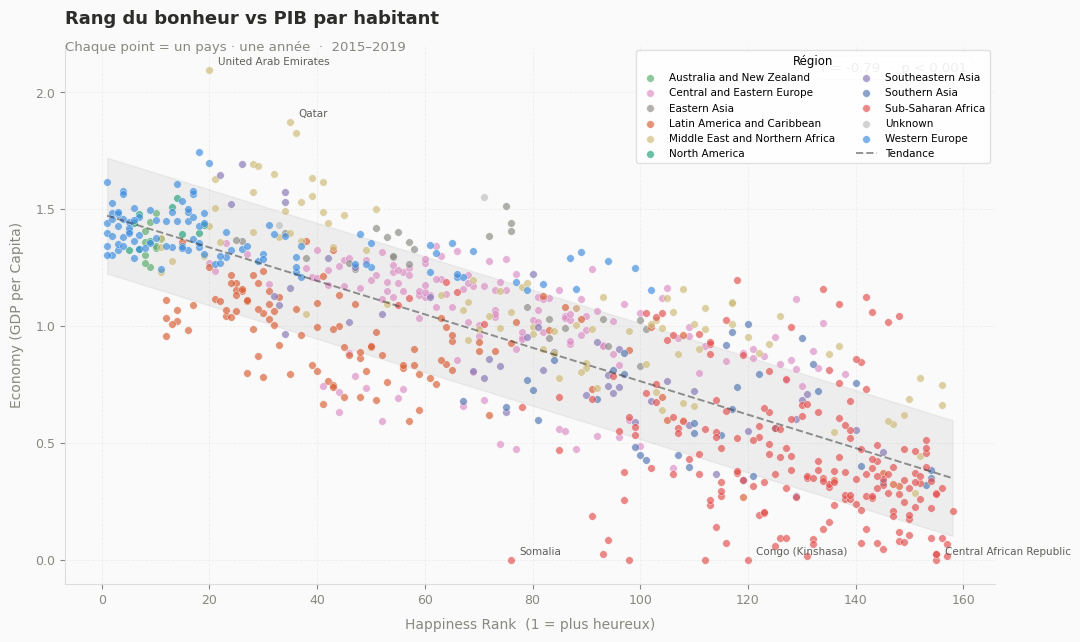

In [ ]:
from scipy.stats import pearsonr
# Corrélation
clean = df[['Happiness Rank', 'Economy (GDP per Capita)']].dropna()
r, p = pearsonr(clean['Happiness Rank'], clean['Economy (GDP per Capita)'])

# Couleurs par région
REGION_COLORS = {
    'Western Europe'                  : '#378ADD',
    'North America'                   : '#1D9E75',
    'Australia and New Zealand'       : '#55A868',
    'Middle East and Northern Africa' : '#CCB974',
    'Latin America and Caribbean'     : '#D85A30',
    'Southeastern Asia'               : '#8172B2',
    'Central and Eastern Europe'      : '#DA8BC3',
    'Eastern Asia'                    : '#888780',
    'Sub-Saharan Africa'              : '#E24B4A',
    'Southern Asia'                   : '#4C72B0',
    'Unknown'                         : '#BBBBBB',
}

# Figure
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Scatter coloré par région
for region, grp in df.groupby('Region'):
    ax.scatter(
        grp['Happiness Rank'],
        grp['Economy (GDP per Capita)'],
        color=REGION_COLORS.get(region, '#BBBBBB'),
        alpha=0.65,
        s=30,
        edgecolors='white',
        linewidths=0.4,
        label=region,
        zorder=3,
    )

# Droite de tendance
x = clean['Happiness Rank']
y = clean['Economy (GDP per Capita)']
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, m * x_line + b,
        color='#2C2C2A', linewidth=1.4,
        linestyle='--', alpha=0.5,
        zorder=4, label='Tendance')

# Zone de confiance (±1 écart-type résiduel)
y_pred = m * x + b
residuals = y - y_pred
std_res = residuals.std()
ax.fill_between(x_line,
                m * x_line + b - std_res,
                m * x_line + b + std_res,
                color='#2C2C2A', alpha=0.06, zorder=2)

# Annotation corrélation
p_label = 'p < 0.001' if p < 0.001 else f'p = {p:.3f}'
ax.text(0.97, 0.97,
        f'r = {r:.2f}  ·  {p_label}',
        transform=ax.transAxes,
        fontsize=9.5, color='#5F5E5A',
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='white',
                  edgecolor='#DDDDDD',
                  linewidth=0.8))

# Annoter quelques pays extrêmes
extremes = pd.concat([
    df.nlargest(3, 'Economy (GDP per Capita)'),
    df.nsmallest(3, 'Economy (GDP per Capita)'),
])
for _, row in extremes.drop_duplicates('Country').iterrows():
    ax.annotate(
        row['Country'],
        (row['Happiness Rank'], row['Economy (GDP per Capita)']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=7.5, color='#5F5E5A',
        arrowprops=dict(arrowstyle='-', color='#CCCCCC', lw=0.6),
    )

# Grille discrète
ax.grid(True, color='#EEEEEE', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

# Axes
ax.tick_params(axis='both', labelsize=9, colors='#888780')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color('#DDDDDD')

ax.set_xlabel('Happiness Rank  (1 = plus heureux)', fontsize=10,
              color='#888780', labelpad=8)
ax.set_ylabel('Economy (GDP per Capita)', fontsize=10,
              color='#888780', labelpad=8)

# Titre & sous-titre
fig.text(0.0, 1.04,
         'Rang du bonheur vs PIB par habitant',
         fontsize=13, fontweight='600', color='#2C2C2A',
         transform=ax.transAxes)
fig.text(0.0, 0.99,
         'Chaque point = un pays · une année  ·  2015–2019',
         fontsize=9.5, color='#888780',
         transform=ax.transAxes)

# Légende
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    fontsize=7.5,
    loc='upper right',
    ncol=2,
    frameon=True,
    framealpha=0.9,
    edgecolor='#DDDDDD',
    title='Région',
    title_fontsize=8.5,
);

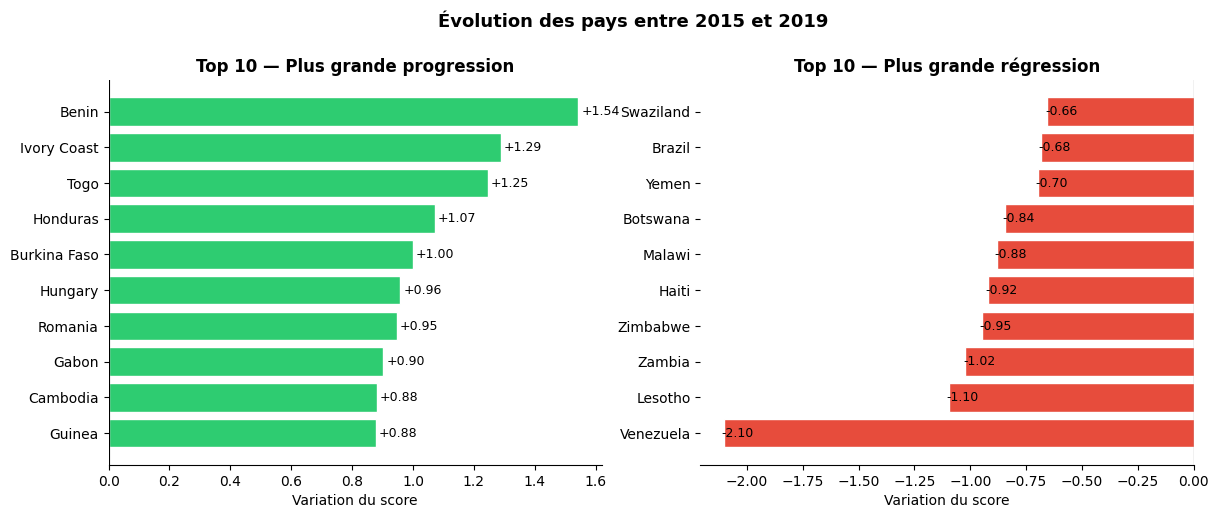

In [ ]:
score_15 = df[df['Year']==2015].set_index('Country')['Happiness Score']
score_19 = df[df['Year']==2019].set_index('Country')['Happiness Score']

delta = (score_19 - score_15).dropna().sort_values()
top_gain = delta.tail(10)
top_loss = delta.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, color in zip(
        axes,
        [top_gain, top_loss],
        ['Top 10 — Plus grande progression', 'Top 10 — Plus grande régression'],
        ['#2ecc71', '#e74c3c']):
    bars = ax.barh(data.index, data.values, color=color, edgecolor='white')
    for bar, val in zip(bars, data.values):
        ax.text(val + (0.01 if val >= 0 else -0.01),
                bar.get_y() + bar.get_height()/2,
                f'{val:+.2f}', va='center', fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Variation du score', fontsize=10)
    sns.despine(ax=ax, left=True)

plt.suptitle('Évolution des pays entre 2015 et 2019',
             fontsize=13, fontweight='bold', y=1.02);


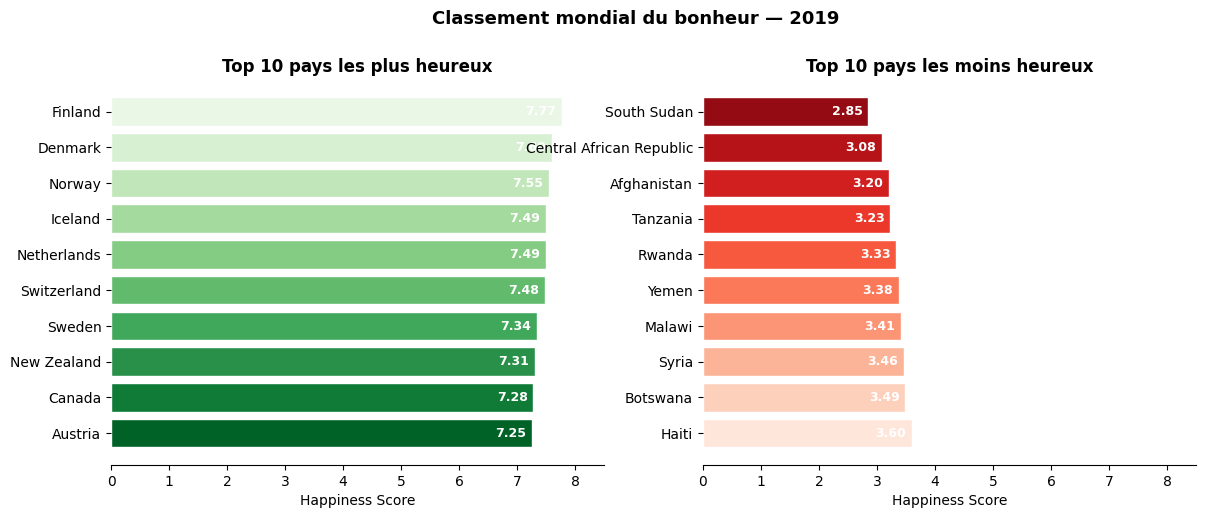

In [ ]:
df_2019 = df[df['Year'] == 2019].copy()

top10    = df_2019.nlargest(10, 'Happiness Score')
bottom10 = df_2019.nsmallest(10, 'Happiness Score')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, pal in zip(
        axes,
        [top10.sort_values('Happiness Score'),
         bottom10.sort_values('Happiness Score', ascending=False)],
        ['Top 10 pays les plus heureux', 'Top 10 pays les moins heureux'],
        ['Greens_r', 'Reds']):

    colors = sns.color_palette(pal, len(data))
    bars = ax.barh(data['Country'], data['Happiness Score'],
                   color=colors, edgecolor='white')
    for bar, val in zip(bars, data['Happiness Score']):
        ax.text(val - 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', ha='right',
                fontsize=9, color='white', fontweight='bold')
    ax.set_xlim(0, 8.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Happiness Score', fontsize=10)
    sns.despine(ax=ax, left=True)

plt.suptitle('Classement mondial du bonheur — 2019',
             fontsize=13, fontweight='bold', y=1.02);

In [ ]:
REGION_COLORS = {
    'Western Europe'                  : '#4C72B0',
    'North America'                   : '#DD8452',
    'Australia and New Zealand'       : '#55A868',
    'Middle East and Northern Africa' : '#C44E52',
    'Latin America and Caribbean'     : '#8172B2',
    'Southeastern Asia'               : '#937860',
    'Central and Eastern Europe'      : '#DA8BC3',
    'Eastern Asia'                    : '#8C8C8C',
    'Sub-Saharan Africa'              : '#CCB974',
    'Southern Asia'                   : '#64B5CD',
    'Unknown'                         : '#BBBBBB',
}

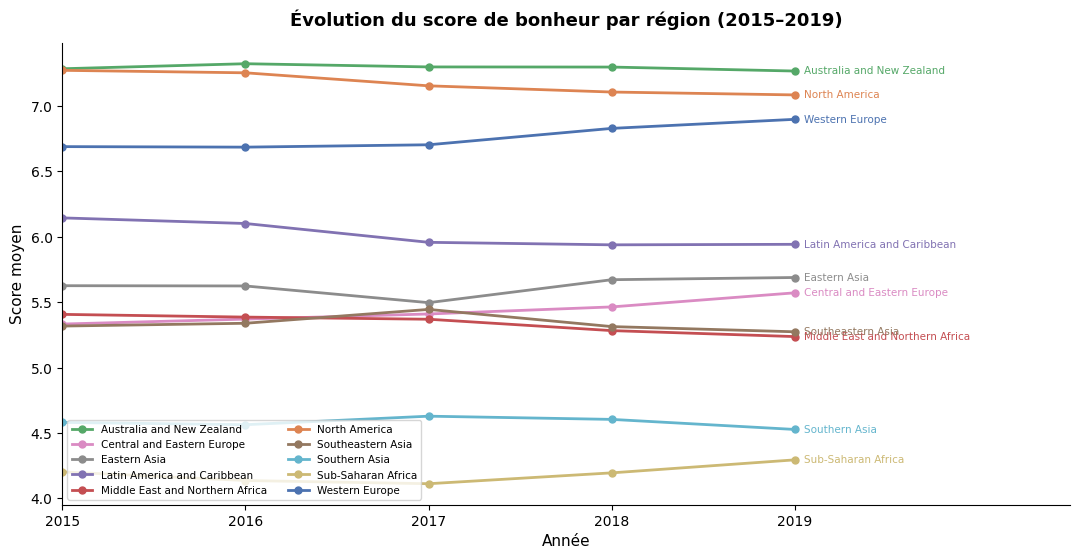

In [ ]:
region_year = (df[df['Region'] != 'Unknown'].groupby(['Year', 'Region'])['Happiness Score'].mean().reset_index())

fig, ax = plt.subplots(figsize=(13, 6))

for region, grp in region_year.groupby('Region'):
    ax.plot(grp['Year'], grp['Happiness Score'],marker='o', linewidth=2, markersize=5,
            color=REGION_COLORS.get(region, '#BBBBBB'),label=region)
    # Label en fin de ligne
    last = grp.sort_values('Year').iloc[-1]
    ax.text(last['Year'] + 0.05, last['Happiness Score'],
            region, fontsize=7.5, va='center',
            color=REGION_COLORS.get(region, '#BBBBBB'))

ax.set_title('Évolution du score de bonheur par région (2015–2019)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Score moyen', fontsize=11)
ax.set_xticks([2015, 2016, 2017, 2018, 2019])
ax.set_xlim(2015, 2020.5)
ax.legend(loc='lower left', fontsize=7.5, ncol=2)
sns.despine();

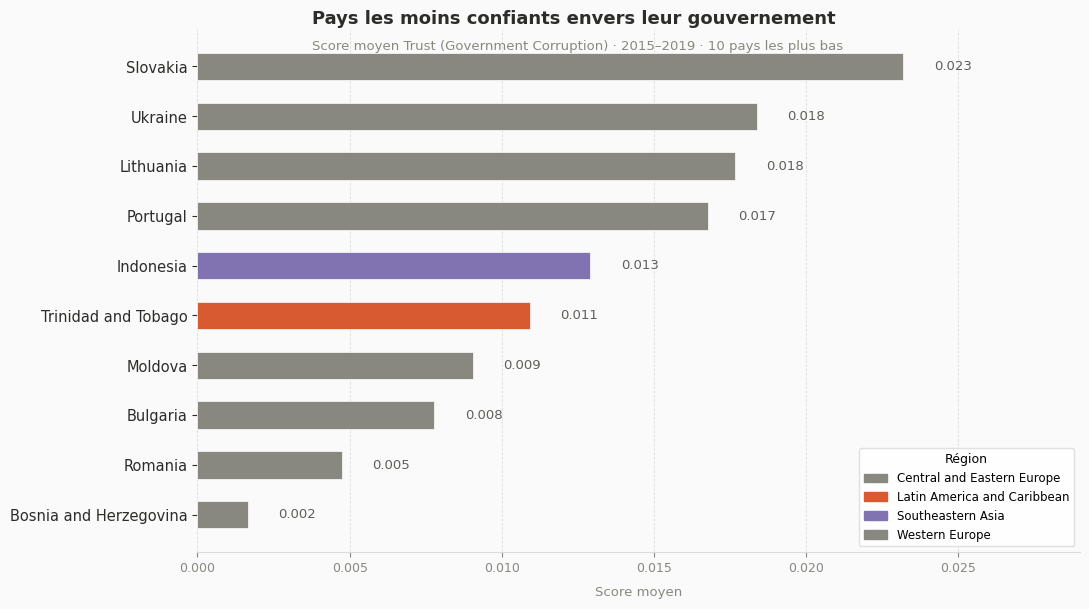

In [ ]:
# Données
trust_data = (df.groupby(['Country', 'Region'])['Trust (Government Corruption)']
              .mean()
              .reset_index()
              .sort_values('Trust (Government Corruption)')
              .head(10))

# Couleurs par région
REGION_COLORS = {
    'Sub-Saharan Africa'          : '#1D9E75',
    'Latin America and Caribbean' : '#D85A30',
    'Southern Asia'               : '#378ADD',
    'Southeastern Asia'           : '#8172B2',
    'Middle East and Northern Africa': '#CCB974',
}
DEFAULT_COLOR = '#888780'

colors = [REGION_COLORS.get(r, DEFAULT_COLOR)
          for r in trust_data['Region']]

# Figure
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(
    trust_data['Country'],
    trust_data['Trust (Government Corruption)'],
    color=colors,
    height=0.55,
    edgecolor='white',
    linewidth=0.5,
)

# Labels de valeur
for bar, val in zip(bars, trust_data['Trust (Government Corruption)']):
    ax.text(
        val + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left',
        fontsize=9.5, color='#5F5E5A', fontweight='500'
    )

# Grille discrète
ax.xaxis.grid(True, color='#DDDDDD', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

# Axes
ax.set_xlim(0, trust_data['Trust (Government Corruption)'].max() * 1.25)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax.tick_params(axis='x', labelsize=9, colors='#888780')
ax.tick_params(axis='y', labelsize=10.5, colors='#2C2C2A')

# Supprimer les bordures inutiles
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')

# Titre & sous-titre
fig.text(0.13, 1.01,
         'Pays les moins confiants envers leur gouvernement',
         fontsize=13, fontweight='600', color='#2C2C2A',
         transform=ax.transAxes)
fig.text(0.13, 0.96,
         'Score moyen Trust (Government Corruption) · 2015–2019 · 10 pays les plus bas',
         fontsize=9.5, color='#888780',
         transform=ax.transAxes)

# Légende
regions_present = trust_data['Region'].unique()
legend_patches = [
    mpatches.Patch(color=REGION_COLORS.get(r, DEFAULT_COLOR), label=r)
    for r in regions_present
]
ax.legend(
    handles=legend_patches,
    loc='lower right',
    fontsize=8.5,
    frameon=True,
    framealpha=0.9,
    edgecolor='#DDDDDD',
    title='Région',
    title_fontsize=9,
)

ax.set_xlabel('Score moyen', fontsize=9.5, color='#888780', labelpad=8)
ax.set_ylabel('')

plt.tight_layout()
plt.show()

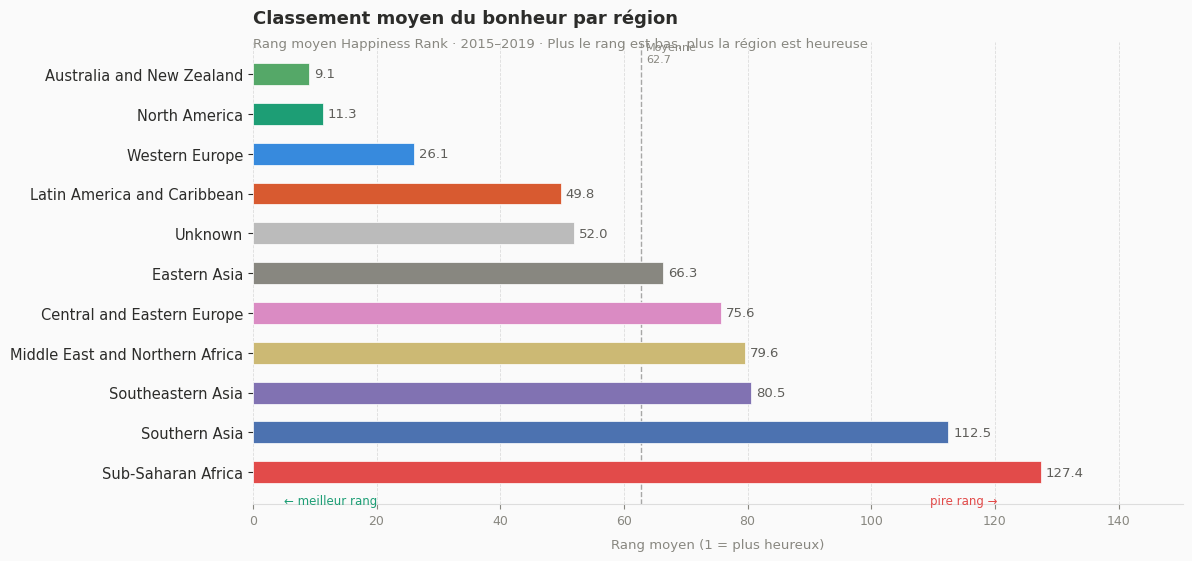

In [ ]:
# Données
rank_data = (df.groupby('Region')['Happiness Rank']
             .mean()
             .sort_values(ascending=False)  # ascending=False → meilleur rang en haut
             .reset_index())

# Couleurs par région
REGION_COLORS = {
    'Western Europe'                  : '#378ADD',
    'North America'                   : '#1D9E75',
    'Australia and New Zealand'       : '#55A868',
    'Middle East and Northern Africa' : '#CCB974',
    'Latin America and Caribbean'     : '#D85A30',
    'Southeastern Asia'               : '#8172B2',
    'Central and Eastern Europe'      : '#DA8BC3',
    'Eastern Asia'                    : '#888780',
    'Sub-Saharan Africa'              : '#E24B4A',
    'Southern Asia'                   : '#4C72B0',
    'Unknown'                         : '#BBBBBB',
}

colors = [REGION_COLORS.get(r, '#BBBBBB') for r in rank_data['Region']]

# Figure
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.barh(
    rank_data['Region'],
    rank_data['Happiness Rank'],
    color=colors,
    height=0.55,
    edgecolor='white',
    linewidth=0.5,
)

# Labels de valeur
for bar, val in zip(bars, rank_data['Happiness Rank']):
    ax.text(
        val + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}',
        va='center', ha='left',
        fontsize=9.5, color='#5F5E5A', fontweight='500'
    )

# Annotation "meilleur - pire"
ax.annotate('← meilleur rang',
            xy=(5, -0.8), fontsize=8.5, color='#1D9E75',
            fontweight='500')
ax.annotate('pire rang →',
            xy=(rank_data['Happiness Rank'].max() - 18, -0.8),
            fontsize=8.5, color='#E24B4A', fontweight='500')

# Ligne moyenne mondiale
mean_rank = rank_data['Happiness Rank'].mean()
ax.axvline(mean_rank, color='#2C2C2A', linestyle='--',
           linewidth=1, alpha=0.4, zorder=0)
ax.text(mean_rank + 0.8, len(rank_data) - 0.2,
        f'Moyenne\n{mean_rank:.1f}',
        fontsize=8, color='#888780', va='top')

# Grille discrète
ax.xaxis.grid(True, color='#DDDDDD', linewidth=0.6, linestyle='--')
ax.set_axisbelow(True)

# Axes
ax.set_xlim(0, rank_data['Happiness Rank'].max() * 1.18)
ax.tick_params(axis='x', labelsize=9, colors='#888780')
ax.tick_params(axis='y', labelsize=10.5, colors='#2C2C2A')

# Supprimer les bordures inutiles
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')

# Titre & sous-titre
fig.text(0.0, 1.04,
         'Classement moyen du bonheur par région',
         fontsize=13, fontweight='600', color='#2C2C2A',
         transform=ax.transAxes)
fig.text(0.0, 0.99,
         'Rang moyen Happiness Rank · 2015–2019 · Plus le rang est bas, plus la région est heureuse',
         fontsize=9.5, color='#888780',
         transform=ax.transAxes)

ax.set_xlabel('Rang moyen (1 = plus heureux)', fontsize=9.5,
              color='#888780', labelpad=8)
ax.set_ylabel('');